# 3.4 — Opciones americanas: parada óptima, frontera libre y aproximaciones

Hasta aquí el ejercicio estaba fijado por contrato: en 3.1-3.3 el tenedor no decide *cuándo* cobrar, sólo *cuánto* cobra en $T$. Casi todas las opciones listadas sobre acciones son **americanas**: el tenedor puede ejercer en cualquier momento $t\in[0,T]$. Eso cambia la naturaleza del problema. El precio ya no es una esperanza de un payoff en una fecha conocida, sino un **supremo sobre estrategias de parada**,
$$
V_0 = \sup_{\tau\,\in\,\mathcal{T}_{[0,T]}} \mathbb{E}^{\mathbb{Q}}\big[e^{-r\tau}\,g(S_\tau)\big],
$$
donde $\mathcal{T}$ son los tiempos de parada de la filtración (no cualquier regla: no se puede parar mirando el futuro) y $g$ es el payoff intrínseco. Esa libertad extra tiene un precio — la **prima de ejercicio anticipado** $V_A - V_E \geq 0$ — y una geometría propia: el espacio $(S,t)$ se parte en una región de continuación y una de ejercicio, separadas por una **frontera libre** $S^*(t)$ que no se conoce de antemano y que hay que resolver *junto con* el precio.

El plan del notebook es ir de lo discreto a lo continuo y de lo exacto a lo aproximado: (§1) la envolvente de Snell, que convierte el supremo sobre tiempos de parada en la inducción hacia atrás del árbol de 2.2 con un `max` en cada nodo; (§2) la formulación de frontera libre de la PDE y las condiciones de *smooth pasting*; (§3) el único caso con solución cerrada exacta, el put perpetuo, donde la frontera es un número y sale de resolver una ODE; (§6) la aproximación cuadrática de Barone-Adesi-Whaley, el estándar de mesa cuando hay que valuar miles de americanas por segundo; y (§8) por qué, sin dividendos, el call americano no vale más que el europeo — el único caso en que toda esta maquinaria es innecesaria.

## 0. Configuración

Este notebook no usa Monte Carlo: árboles, ODEs y raíces son deterministas, así que no hay `rng` ni bandas de error muestral — las tolerancias de la §10 son puramente de discretización.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm

from qflib.black import bs_price, bs_delta
from qflib.plotting import apply_style

apply_style()

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0

print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"Put europeo (qflib.black.bs_price)  = {bs_price(S0, K, r, q, sigma, T, 'put'):.6f}")
print(f"Call europeo (qflib.black.bs_price) = {bs_price(S0, K, r, q, sigma, T, 'call'):.6f}")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
Put europeo (qflib.black.bs_price)  = 5.573526
Call europeo (qflib.black.bs_price) = 10.450584


## 1. Parada óptima y la envolvente de Snell

Trabajemos primero en tiempo discreto, $i=0,1,\dots,N$ con $t_i=i\Delta t$, que es donde todo se puede construir a mano. Sea $Z_i=g(S_i)$ el payoff intrínseco y $D_i=e^{-rt_i}$ el descuento. Definimos hacia atrás la **envolvente de Snell** del payoff descontado:
$$
U_N = Z_N, \qquad U_i = \max\Big\{\,Z_i,\ \ e^{-r\Delta t}\,\mathbb{E}^{\mathbb{Q}}_i\big[U_{i+1}\big]\Big\}, \quad i<N.
$$
La lectura financiera de cada término es literal: $Z_i$ es lo que se cobra ejerciendo ahora, y $e^{-r\Delta t}\mathbb{E}_i[U_{i+1}]$ es el **valor de continuación**, lo que vale seguir con la opción viva un paso más y actuar óptimamente después. La opción vale el máximo de las dos.

**Teorema (envolvente de Snell).** $D_iU_i$ es el supermartingala más pequeño que domina a $D_iZ_i$, y
$$
U_0 = \sup_{\tau\leq N}\mathbb{E}^{\mathbb{Q}}\big[D_\tau Z_\tau\big], \qquad \tau^* = \min\{i:\ U_i = Z_i\}\ \text{ es óptimo.}
$$

*Demostración (esquema).* (i) *Supermartingala:* por construcción $U_i \geq e^{-r\Delta t}\mathbb{E}_i[U_{i+1}]$, es decir $D_iU_i\geq\mathbb{E}_i[D_{i+1}U_{i+1}]$. (ii) *Domina:* $U_i\geq Z_i$ por el `max`. (iii) *Cota superior:* para cualquier tiempo de parada $\tau$, el teorema de muestreo opcional aplicado al supermartingala da $\mathbb{E}[D_\tau U_\tau]\leq U_0$, y como $U_\tau\geq Z_\tau$, entonces $\mathbb{E}[D_\tau Z_\tau]\leq U_0$: **ningún** $\tau$ supera $U_0$. (iv) *Se alcanza:* el proceso **detenido** en $\tau^*$ sí es martingala — antes de $\tau^*$ se tiene $U_i>Z_i$, y ahí el `max` lo gana la continuación, o sea $U_i=e^{-r\Delta t}\mathbb{E}_i[U_{i+1}]$ con igualdad. Luego $U_0=\mathbb{E}[D_{\tau^*}U_{\tau^*}]=\mathbb{E}[D_{\tau^*}Z_{\tau^*}]$, alcanzando la cota. $\blacksquare$

Y aquí está la conexión con 2.2: **en el árbol binomial la esperanza condicional es una suma de dos términos**, así que la recursión de Snell *es* exactamente la inducción hacia atrás del árbol con un `max` extra en cada nodo:
$$
V_{i,j} = \max\Big\{\,g(S_{i,j}),\ \ e^{-r\Delta t}\big[p\,V_{i+1,j+1} + (1-p)\,V_{i+1,j}\big]\Big\}.
$$
Los nodos donde gana $g(S_{i,j})$ forman la **región de ejercicio**; los demás, la de continuación. La frontera entre ambas, leída del árbol, es nuestra primera estimación numérica de $S^*(t)$.

Usamos la probabilidad de no arbitraje exacta $p=(e^{(r-q)\Delta t}-d)/(u-d)$ de 2.2 §1.2, la que hace que $\mathbb{E}_i[S_{i+1}]=S_ie^{(r-q)\Delta t}$ se cumpla **exactamente** en cada paso. QuantLib usa en cambio la versión linealizada $p\approx\tfrac12+\tfrac12(r-q-\tfrac{\sigma^2}{2})\Delta t/(\sigma\sqrt{\Delta t})$; las dos convergen al mismo límite pero difieren en $O(\Delta t)$, y en la §10 verificamos que la discrepancia entre ambos árboles decae exactamente como $1/n$.

In [2]:
def crr_american(S0, K, r, q, sigma, T, n_steps, kind="put", american=True, keep_layers=()):
    '''Price a vanilla option on a CRR tree by the Snell recursion of Section 1.

    Returns (price, boundary, layers):
      boundary[i] = exercise boundary S*(t_i), geometric midpoint between the extreme
                    exercising node and its neighbour in the continuation region;
                    NaN where the lattice at step i has no node in the exercise region.
      layers[i]   = (S, V) arrays at step i, for the steps listed in keep_layers.
    '''
    dt = T / n_steps
    u = np.exp(sigma * np.sqrt(dt))
    p = (np.exp((r - q) * dt) - 1.0 / u) / (u - 1.0 / u)
    if not 0.0 < p < 1.0:
        raise ValueError(f"no-arbitrage violated: p={p:.6f} not in (0,1)")
    disc = np.exp(-r * dt)
    sign = 1.0 if kind == "call" else -1.0
    intrinsic = lambda S: np.maximum(sign * (S - K), 0.0)

    # S_levels(i)[j] = S0 * u^(2j - i), j = 0..i  (j = number of up moves)
    S_at = lambda i: S0 * u ** (2.0 * np.arange(i + 1) - i)

    V = intrinsic(S_at(n_steps))
    boundary = np.full(n_steps + 1, np.nan)
    layers = {}
    for i in range(n_steps - 1, -1, -1):
        V = disc * (p * V[1:] + (1.0 - p) * V[:-1])  # continuation value
        S_i = S_at(i)
        if american:
            exercise = intrinsic(S_i) > V
            if exercise.any():
                if kind == "put":  # exercise region is S <= S*, take the highest such node
                    j = int(np.flatnonzero(exercise)[-1])
                    neighbour = j + 1
                else:              # exercise region is S >= S*, take the lowest such node
                    j = int(np.flatnonzero(exercise)[0])
                    neighbour = j - 1
                if 0 <= neighbour <= i:
                    boundary[i] = np.sqrt(S_i[j] * S_i[neighbour])  # lattice is geometric
                else:
                    boundary[i] = S_i[j]
            V = np.where(exercise, intrinsic(S_i), V)
        if i in keep_layers:
            layers[i] = (S_i, V.copy())
    return V[0], boundary, layers


put_am_2000, _, _ = crr_american(S0, K, r, q, sigma, T, 2000, "put")
put_eu_2000, _, _ = crr_american(S0, K, r, q, sigma, T, 2000, "put", american=False)
print(f"Put americano (CRR n=2000) = {put_am_2000:.6f}")
print(f"Put europeo   (CRR n=2000) = {put_eu_2000:.6f}   [BS exacto = {bs_price(S0, K, r, q, sigma, T, 'put'):.6f}]")
print(f"Prima de ejercicio anticipado = {put_am_2000 - put_eu_2000:.6f}")

Put americano (CRR n=2000) = 6.089990
Put europeo   (CRR n=2000) = 5.572526   [BS exacto = 5.573526]
Prima de ejercicio anticipado = 0.517464


## 2. La formulación de frontera libre y el *smooth pasting*

Pasando al límite continuo, en la **región de continuación** la opción americana no se ejerce, así que la cartera de réplica de 3.1 funciona igual y $V$ satisface la misma PDE de Black-Scholes; en la **región de ejercicio** simplemente $V=g$. Para un put:
$$
\frac{\partial V}{\partial t} + \mathcal{L}V = 0 \quad\text{para } S>S^*(t), \qquad V(S,t)=K-S \quad\text{para } S\leq S^*(t),
$$
con $\mathcal{L}V=\tfrac12\sigma^2S^2\partial_{SS}V+(r-q)S\partial_SV-rV$. Lo incómodo es que $S^*(t)$ es **parte de la incógnita**: no es un dato de frontera, es un objeto a resolver junto con $V$ — de ahí el nombre *free boundary problem*. Las dos condiciones que lo cierran en $S=S^*(t)$ son
$$
\underbrace{V(S^*(t),t) = K - S^*(t)}_{\text{value matching}}, \qquad \underbrace{\frac{\partial V}{\partial S}(S^*(t),t) = -1}_{\text{smooth pasting}}.
$$
La primera es continuidad. La segunda no es un supuesto de regularidad gratuito, es una **condición de optimalidad**: pensemos en la familia de estrategias "ejercer al tocar el nivel $b$", con valor $V_b(S)$. Elegir $b$ óptimo exige $\partial V_b/\partial b=0$ en $b=S^*$, y al derivar la condición de value matching $V_b(b)=K-b$ respecto de $b$ se obtiene $\partial_SV_b(b)+\partial_bV_b(b)=-1$; imponiendo la optimalidad $\partial_bV_b(b)=0$ queda $\partial_SV(S^*)=-1$. Si la pendiente no empatara, la curva de valor cruzaría el payoff con un pico y mover el nivel un poco mejoraría la estrategia — se puede ver explícitamente en el put perpetuo de la §3, donde $b\mapsto V_b(S)$ es una función suave con un máximo interior.

Las dos regiones juntas se escriben como una **desigualdad variacional** (linear complementarity problem), la forma en que realmente se resuelve numéricamente por PDE en M4:
$$
\min\Big\{-\partial_tV-\mathcal{L}V,\ \ V-g\Big\}=0, \qquad V\geq g.
$$
En cada punto una de las dos expresiones se anula: o vale la PDE (continuación) o vale el payoff (ejercicio); y nunca $V<g$, porque el tenedor siempre puede ejercer. Nótese que es la versión continua de la envolvente de Snell: "el supermartingala más pequeño que domina al payoff".

Un dato útil para leer los gráficos de abajo: en la maduración la frontera vale $S^*(T^-)=K\min(1,r/q)$, que con $q=0$ es simplemente $K$; y $S^*(t)$ es creciente en $t$ (decreciente en el tiempo al vencimiento), acercándose cuando $T-t\to\infty$ al nivel perpetuo de la §3.

## 3. El put perpetuo: solución cerrada exacta

Con $T=\infty$ el problema pierde la dependencia temporal — el tiempo restante es siempre infinito — y la PDE colapsa a una **ODE**. Buscamos $V(S)$ y un nivel constante $S^*$ tales que, para $S>S^*$,
$$
\tfrac12\sigma^2S^2V'' + (r-q)SV' - rV = 0.
$$
Es una ecuación equidimensional: probando $V=S^\beta$ queda la cuadrática característica
$$
\tfrac12\sigma^2\beta(\beta-1) + (r-q)\beta - r = 0 \quad\Longrightarrow\quad \beta_\pm = \frac{-(r-q-\tfrac12\sigma^2)\pm\sqrt{(r-q-\tfrac12\sigma^2)^2+2r\sigma^2}}{\sigma^2},
$$
con $\beta_-<0<1<\beta_+$ (el discriminante es positivo y el producto de raíces es $-2r/\sigma^2<0$). La solución general es $V=A_+S^{\beta_+}+A_-S^{\beta_-}$, y **descartamos** $A_+=0$: un put no puede crecer sin cota cuando $S\to\infty$, ahí debe valer $V\to0$. Queda $V(S)=A\,S^{\beta_-}$, que sí decae.

Ahora imponemos las dos condiciones de la §2 en $S^*$:
$$
A\,(S^*)^{\beta_-} = K-S^*, \qquad A\,\beta_-(S^*)^{\beta_--1} = -1.
$$
Dividiendo la segunda entre la primera se elimina $A$: $\beta_-/S^* = -1/(K-S^*)$, de donde
$$
\boxed{\;S^* = K\,\frac{\beta_-}{\beta_--1}\;}, \qquad A = \frac{K-S^*}{(S^*)^{\beta_-}}, \qquad V(S) = (K-S^*)\Big(\frac{S}{S^*}\Big)^{\beta_-}\ \ (S>S^*).
$$
Como $\beta_-<0$, se tiene $0<\beta_-/(\beta_--1)<1$, así que $S^*<K$: nunca conviene ejercer un put perpetuo apenas entra en el dinero, hay que esperar a que caiga bastante. Con los parámetros canónicos ($r=0.05$, $q=0$, $\sigma=0.2$) los números salen redondos: $r-q-\tfrac12\sigma^2=0.03$, discriminante $0.0009+0.004=0.0049$, $\beta_-=(-0.03-0.07)/0.04=-2.5$ y $S^*=100\cdot(-2.5)/(-3.5)=71.43$.

Este es el único caso americano con fórmula cerrada exacta, y es la referencia natural para dos cosas: es el **límite** al que debe converger el árbol cuando $T$ crece (Demo 1) y es la **cota inferior** de la frontera $S^*(t)$ a plazo finito (Demo 2).

In [3]:
def perpetual_put(S, K, r, q, sigma):
    '''Perpetual American put: value and optimal exercise level (Section 3, Merton 1973).'''
    a = r - q - 0.5 * sigma**2
    beta_minus = (-a - np.sqrt(a**2 + 2.0 * r * sigma**2)) / sigma**2
    S_star = K * beta_minus / (beta_minus - 1.0)
    S = np.asarray(S, dtype=float)
    value = np.where(S > S_star, (K - S_star) * (S / S_star) ** beta_minus, K - S)
    return value, S_star, beta_minus


perp_value, perp_S_star, perp_beta = perpetual_put(S0, K, r, q, sigma)
print(f"beta_- = {perp_beta:.6f}  |  S* = {perp_S_star:.6f}  |  V(S0={S0}) = {float(perp_value):.6f}")

# la condicion de smooth pasting se cumple por construccion: comprobemos la pendiente -1 en S*
h = 1e-6
slope = (perpetual_put(perp_S_star + h, K, r, q, sigma)[0] - perpetual_put(perp_S_star - h, K, r, q, sigma)[0]) / (2 * h)
print(f"dV/dS en S* = {float(slope):.10f} (smooth pasting exige -1)")

beta_- = -2.500000  |  S* = 71.428571  |  V(S0=100.0) = 12.320033
dV/dS en S* = -0.9999999886 (smooth pasting exige -1)


## 4. Demo 1 — el put perpetuo como límite del árbol con $T$ grande

El árbol binomial con vencimiento cada vez más lejano debe acercarse al valor perpetuo **por abajo**: un put a plazo finito nunca vale más que el perpetuo, porque el conjunto de estrategias de parada admisibles es más chico. Tomamos $T\in\{10,25,50,100\}$ manteniendo $\Delta t$ fijo en $1/200$ (o sea $n=200\,T$), para que el error de discretización no contamine el error de truncamiento del horizonte, y verificamos también la geometría: la curva del valor perpetuo despegándose del payoff justo en $S^*$, tangente a él (pendiente $-1$).

Valor perpetuo (analitico) = 12.320033   (S* = 71.4286)
     T |      n |   binomial |      error |  error rel
------------------------------------------------------


    10 |   2000 |  11.209513 |  -1.110520 |  -9.0139%


    25 |   5000 |  12.123069 |  -0.196964 |  -1.5987%


    50 |  10000 |  12.298658 |  -0.021374 |  -0.1735%


   100 |  20000 |  12.317920 |  -0.002113 |  -0.0172%


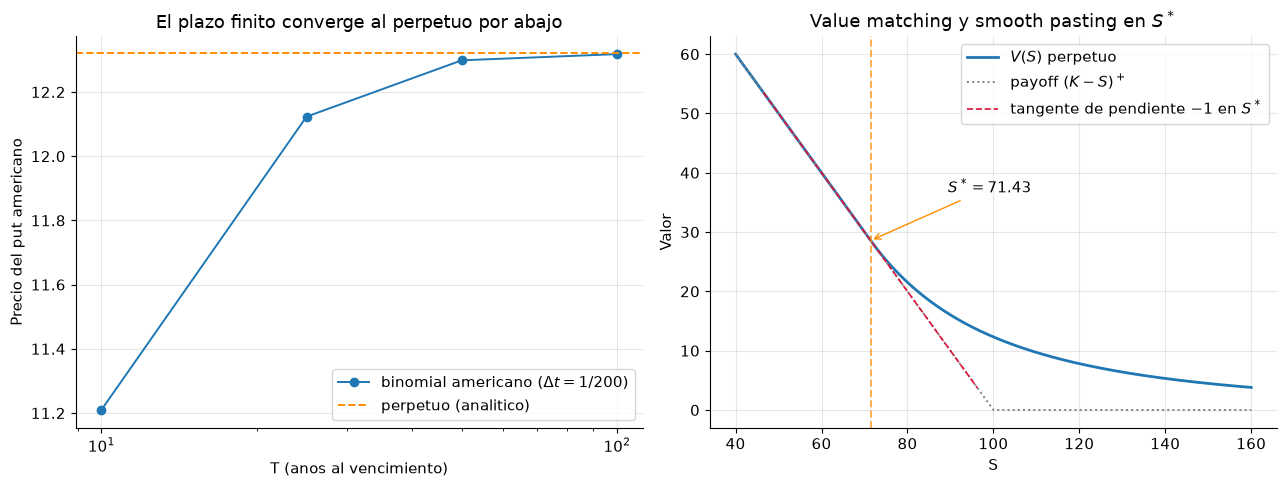

In [4]:
print(f"Valor perpetuo (analitico) = {float(perp_value):.6f}   (S* = {perp_S_star:.4f})")
print(f"{'T':>6} | {'n':>6} | {'binomial':>10} | {'error':>10} | {'error rel':>10}")
print("-" * 54)
T_horizons = [10, 25, 50, 100]
perp_binomial = []
for T_h in T_horizons:
    n_h = 200 * T_h
    v, _, _ = crr_american(S0, K, r, q, sigma, T_h, n_h, "put")
    perp_binomial.append(v)
    print(f"{T_h:>6} | {n_h:>6} | {v:>10.6f} | {v - float(perp_value):>10.6f} | {(v - float(perp_value)) / float(perp_value):>9.4%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(T_horizons, perp_binomial, "o-", label="binomial americano ($\\Delta t = 1/200$)")
ax.axhline(float(perp_value), color="darkorange", ls="--", label="perpetuo (analitico)")
ax.set_xscale("log")
ax.set_xlabel("T (anos al vencimiento)"); ax.set_ylabel("Precio del put americano")
ax.set_title("El plazo finito converge al perpetuo por abajo")
ax.legend()

ax = axes[1]
S_grid = np.linspace(40.0, 160.0, 500)
v_perp, _, _ = perpetual_put(S_grid, K, r, q, sigma)
ax.plot(S_grid, v_perp, lw=2, label="$V(S)$ perpetuo")
ax.plot(S_grid, np.maximum(K - S_grid, 0.0), color="gray", ls=":", label="payoff $(K-S)^+$")
tangent_mask = (S_grid > perp_S_star - 25) & (S_grid < perp_S_star + 25)
ax.plot(S_grid[tangent_mask], (K - perp_S_star) - (S_grid[tangent_mask] - perp_S_star),
        color="crimson", ls="--", lw=1.2, label="tangente de pendiente $-1$ en $S^*$")
ax.axvline(perp_S_star, color="darkorange", ls="--", alpha=0.7)
ax.annotate(f"$S^* = {perp_S_star:.2f}$", xy=(perp_S_star, K - perp_S_star),
            xytext=(perp_S_star + 18, K - perp_S_star + 8),
            arrowprops=dict(arrowstyle="->", color="darkorange"))
ax.set_xlabel("S"); ax.set_ylabel("Valor")
ax.set_title("Value matching y smooth pasting en $S^*$")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Demo 2 — la frontera de ejercicio $S^*(t)$ leída del árbol

La región de ejercicio del árbol da la frontera directamente: en cada paso $i$ tomamos el nodo más alto donde ejercer domina y lo interpolamos geométricamente con su vecino de la región de continuación. Dos advertencias honestas sobre lo que la retícula puede y no puede resolver: (i) cerca de $t=0$ la capa $i$ tiene apenas $i+1$ nodos, ninguno tan abajo como $S^*$, así que la frontera no está definida ahí (la retícula no *llega*); (ii) la frontera resultante es una escalera con paso $\sim\sigma\sqrt{\Delta t}$ en log-espacio, no una curva suave — de ahí el ruido visible en el gráfico.

Comparamos la frontera de un árbol con $T=1$ y otro con $T=5$ contra el nivel perpetuo $S^*=71.43$: como anticipó la §2, $S^*(t)$ arranca en $K$ en el vencimiento y baja monótonamente al alejarse de él, con el perpetuo como asíntota inferior. Nótese en el panel izquierdo que las dos fronteras **coinciden donde se solapan**: $S^*$ no depende de $T$ sino sólo del tiempo al vencimiento $T-t$, como debe ser en un modelo con coeficientes constantes — el árbol de $T=5$ es simplemente el de $T=1$ extendido hacia la izquierda. En el panel derecho tomamos una capa intermedia del árbol ($t=T/2$) para ver el *smooth pasting* en un plazo finito: $V(\cdot,t)$ pegándose tangencialmente al payoff en $S^*(t)$.

T=1: la frontera queda definida desde i=47 (t=0.0235); S*(t=0.024) = 81.4062
T=1: S*(t=T/2) = 83.9950 | S*(t->T) = 100.0000 (teoria: K = 100.0 con q=0)
T=5: S*(t=0.03) = 75.5784 | nivel perpetuo = 71.4286


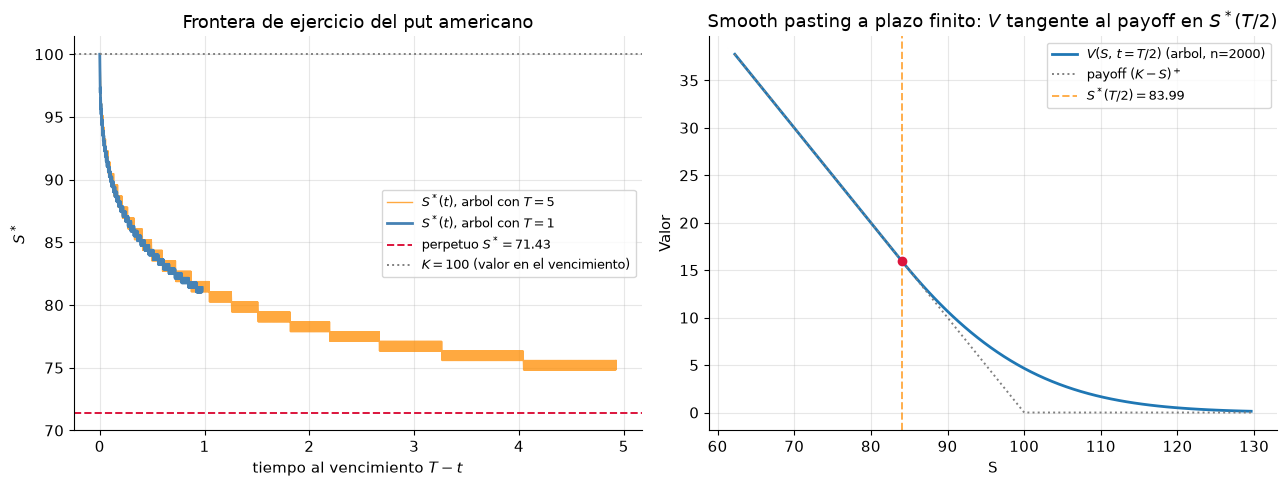

In [5]:
n_bnd = 2000
i_half = n_bnd // 2
_, bnd_T1, layers_T1 = crr_american(S0, K, r, q, sigma, T, n_bnd, "put", keep_layers=(i_half,))
_, bnd_T5, _ = crr_american(S0, K, r, q, sigma, 5.0, n_bnd, "put")

t_T1 = np.linspace(0.0, T, n_bnd + 1)
t_T5 = np.linspace(0.0, 5.0, n_bnd + 1)
first_defined = int(np.flatnonzero(~np.isnan(bnd_T1))[0])
print(f"T=1: la frontera queda definida desde i={first_defined} (t={t_T1[first_defined]:.4f}); "
      f"S*(t={t_T1[first_defined]:.3f}) = {bnd_T1[first_defined]:.4f}")
print(f"T=1: S*(t=T/2) = {bnd_T1[i_half]:.4f} | S*(t->T) = {bnd_T1[n_bnd-1]:.4f} (teoria: K = {K} con q=0)")
print(f"T=5: S*(t=0.03) = {bnd_T5[int(np.flatnonzero(~np.isnan(bnd_T5))[0])]:.4f} "
      f"| nivel perpetuo = {perp_S_star:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(5.0 - t_T5, bnd_T5, lw=1.0, color="darkorange", alpha=0.75, label="$S^*(t)$, arbol con $T=5$")
ax.plot(T - t_T1, bnd_T1, lw=2.0, color="steelblue", label="$S^*(t)$, arbol con $T=1$")
ax.axhline(perp_S_star, color="crimson", ls="--", label=f"perpetuo $S^*={perp_S_star:.2f}$")
ax.axhline(K, color="gray", ls=":", label=f"$K={K:.0f}$ (valor en el vencimiento)")
ax.set_xlabel("tiempo al vencimiento $T-t$"); ax.set_ylabel("$S^*$")
ax.set_title("Frontera de ejercicio del put americano")
ax.legend(fontsize=9)

ax = axes[1]
S_layer, V_layer = layers_T1[i_half]
S_star_half = bnd_T1[i_half]
mask = (S_layer > 0.62 * K) & (S_layer < 1.30 * K)
ax.plot(S_layer[mask], V_layer[mask], lw=2, label=f"$V(S,\\,t=T/2)$ (arbol, n={n_bnd})")
ax.plot(S_layer[mask], np.maximum(K - S_layer[mask], 0.0), color="gray", ls=":", label="payoff $(K-S)^+$")
ax.axvline(S_star_half, color="darkorange", ls="--", alpha=0.7,
           label=f"$S^*(T/2) = {S_star_half:.2f}$")
ax.plot([S_star_half], [K - S_star_half], "o", color="crimson", ms=6, zorder=5)
ax.set_xlabel("S"); ax.set_ylabel("Valor")
ax.set_title("Smooth pasting a plazo finito: $V$ tangente al payoff en $S^*(T/2)$")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. La aproximación cuadrática de Barone-Adesi-Whaley

El árbol denso es exacto en el límite pero cuesta $O(n^2)$; una mesa que revalúa miles de americanas por segundo necesita algo cerrado. La idea de MacMillan (1986) y Barone-Adesi-Whaley (1987) es no atacar $V_A$ directamente sino la **prima de ejercicio anticipado**
$$
\varepsilon(S,\tau) = V_A(S,\tau) - V_E(S,\tau), \qquad \tau = T-t,
$$
que por linealidad de la PDE satisface la *misma* ecuación de Black-Scholes (ambos términos la satisfacen en la región de continuación). Se escribe $\varepsilon = \kappa(\tau)\,f(S,\kappa)$ con $\kappa(\tau)=1-e^{-r\tau}$, se sustituye, y llega el **único paso aproximado**: se descarta el término $\kappa(1-\kappa)\,\partial f/\partial \kappa$, argumentando que es pequeño tanto cerca del vencimiento ($\kappa\to0$) como muy lejos de él ($\kappa\to1$). Lo que queda es una ODE equidimensional en $S$ como la del put perpetuo:
$$
\tfrac12\sigma^2S^2f'' + (r-q)Sf' - \frac{r}{\kappa}f = 0,
$$
cuya raíz decreciente, con $M=2r/\sigma^2$ y $N=2(r-q)/\sigma^2$, es
$$
q_1 = \frac{-(N-1)-\sqrt{(N-1)^2+4M/\kappa}}{2} \;<\;0,
$$
así que $\varepsilon = A_1 (S/S^{**})^{q_1}$ para $S>S^{**}$. Nótese que $q_1\to\beta_-$ cuando $\tau\to\infty$ ($\kappa\to1$): **BAW degenera exactamente en el put perpetuo de la §3**, es la misma estructura con el exponente corregido por el plazo finito.

Las dos condiciones de la §2 en la frontera $S^{**}$ (que ahora es la frontera *de hoy* para vencimiento $\tau$) cierran el sistema. Value matching $K-S^{**} = V_E(S^{**}) + A_1$ y smooth pasting $-1 = \partial_SV_E(S^{**}) + A_1q_1/S^{**}$ dan, eliminando $A_1$, la ecuación escalar que hay que resolver numéricamente (un Newton o un Brent, lo único iterativo del método):
$$
K - S^{**} - V_E(S^{**}) + \frac{S^{**}}{q_1}\Big[1 - e^{-q\tau}N(-d_1(S^{**}))\Big] = 0,
$$
usando $\partial_SV_E = -e^{-q\tau}N(-d_1)$ para el put europeo. Con la raíz $S^{**}$ en mano, $A_1 = -\frac{S^{**}}{q_1}[1-e^{-q\tau}N(-d_1(S^{**}))]$ y
$$
V_A^{\text{BAW}}(S) = \begin{cases} V_E(S) + A_1\,(S/S^{**})^{q_1}, & S>S^{**},\\[2pt] K-S, & S\leq S^{**}.\end{cases}
$$

In [6]:
def baw_american_put(S, K, r, q, sigma, T):
    '''Barone-Adesi-Whaley (1987) quadratic approximation for an American put (Section 6).

    Returns (price, S_critical). The only iterative step is the root of the
    value-matching + smooth-pasting equation for the critical price S**.
    '''
    M = 2.0 * r / sigma**2
    N_ = 2.0 * (r - q) / sigma**2
    kappa = 1.0 - np.exp(-r * T)
    q1 = 0.5 * (-(N_ - 1.0) - np.sqrt((N_ - 1.0) ** 2 + 4.0 * M / kappa))

    def d1(x):
        return (np.log(x / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    def boundary_eq(x):  # zero at x = S**
        return (K - x - bs_price(x, K, r, q, sigma, T, "put")
                + (x / q1) * (1.0 - np.exp(-q * T) * norm.cdf(-d1(x))))

    S_crit = brentq(boundary_eq, 1e-8, K, xtol=1e-13, rtol=1e-15, maxiter=500)
    A1 = -(S_crit / q1) * (1.0 - np.exp(-q * T) * norm.cdf(-d1(S_crit)))
    if S <= S_crit:
        return K - S, S_crit
    return bs_price(S, K, r, q, sigma, T, "put") + A1 * (S / S_crit) ** q1, S_crit


baw_price, baw_S_crit = baw_american_put(S0, K, r, q, sigma, T)
print(f"BAW put americano = {baw_price:.6f}  |  S** = {baw_S_crit:.6f}")
print(f"  binomial n=2000  = {put_am_2000:.6f}  (diferencia {baw_price - put_am_2000:+.6f})")
print(f"  europeo exacto   = {bs_price(S0, K, r, q, sigma, T, 'put'):.6f}")
print(f"  S** vs frontera del arbol en t={t_T1[first_defined]:.3f}: {baw_S_crit:.4f} vs {bnd_T1[first_defined]:.4f}")

BAW put americano = 6.097615  |  S** = 81.695434
  binomial n=2000  = 6.089990  (diferencia +0.007625)
  europeo exacto   = 5.573526
  S** vs frontera del arbol en t=0.024: 81.6954 vs 81.4062


## 7. Demo 3 — precisión de BAW contra un árbol denso, en función de $(K,T)$

BAW es una aproximación, así que la pregunta útil no es "¿acierta?" sino "¿dónde y cuánto se equivoca?". Barremos $K\in\{80,90,100,110,120\}$ y $T\in\{0.25,1,3\}$ contra un árbol de $n=4000$ pasos como referencia. El patrón que aparece es el típico reportado en la literatura: el error **absoluto** se mantiene en centésimas incluso a tres años (perfectamente utilizable para cotizar), pero el error **relativo** se dispara donde el precio mismo es diminuto — puts muy fuera del dinero y de plazo corto, donde la prima de ejercicio anticipado es una fracción grande de un número muy chico. Deep in the money ambos métodos devuelven el intrínseco y el error es exactamente cero.

Referencia: arbol CRR americano con n=4000 pasos
     T |      K |   binomial |        BAW |   err abs |   err rel
------------------------------------------------------------------


  0.25 |     80 |    0.02786 |    0.03035 |  +0.00248 |   +8.914%


  0.25 |     90 |    0.56301 |    0.57059 |  +0.00757 |   +1.345%


  0.25 |    100 |    3.47973 |    3.47214 |  -0.00759 |   -0.218%


  0.25 |    110 |   10.33059 |   10.27938 |  -0.05122 |   -0.496%


...

   3.0 |     80 |    2.38334 |    2.50556 |  +0.12223 |   +5.128%


   3.0 |     90 |    4.87659 |    4.99683 |  +0.12024 |   +2.466%


   3.0 |    100 |    8.71032 |    8.77998 |  +0.06966 |   +0.800%


   3.0 |    110 |   14.08704 |   14.06649 |  -0.02054 |   -0.146%


   3.0 |    120 |   21.15011 |   21.06008 |  -0.09003 |   -0.426%


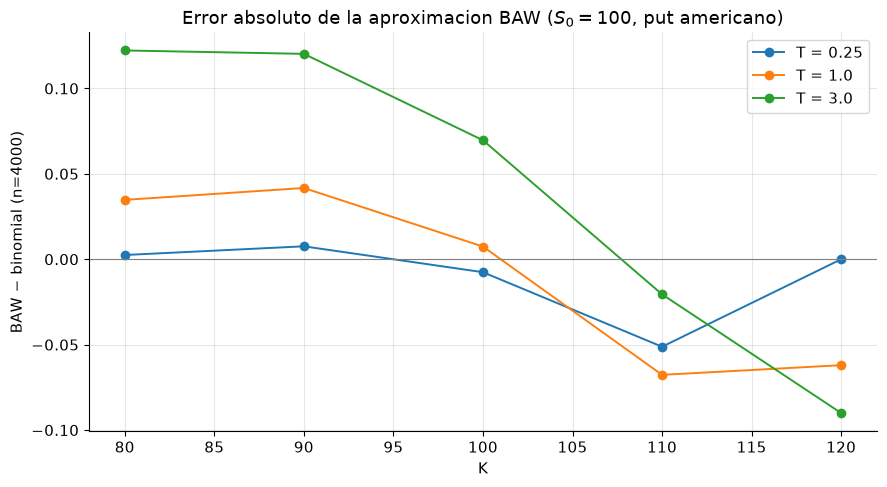

In [7]:
K_grid = [80.0, 90.0, 100.0, 110.0, 120.0]
T_grid = [0.25, 1.0, 3.0]
n_ref = 4000

print(f"Referencia: arbol CRR americano con n={n_ref} pasos")
print(f"{'T':>6} | {'K':>6} | {'binomial':>10} | {'BAW':>10} | {'err abs':>9} | {'err rel':>9}")
print("-" * 66)
err_abs = {T_g: [] for T_g in T_grid}
for T_g in T_grid:
    for K_g in K_grid:
        ref, _, _ = crr_american(S0, K_g, r, q, sigma, T_g, n_ref, "put")
        approx, _ = baw_american_put(S0, K_g, r, q, sigma, T_g)
        err_abs[T_g].append(approx - ref)
        rel = (approx - ref) / ref if ref > 0 else 0.0
        print(f"{T_g:>6} | {K_g:>6.0f} | {ref:>10.5f} | {approx:>10.5f} | {approx - ref:>+9.5f} | {rel:>+9.3%}")

fig, ax = plt.subplots(figsize=(9, 5))
for T_g in T_grid:
    ax.plot(K_grid, err_abs[T_g], "o-", label=f"T = {T_g}")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("K"); ax.set_ylabel("BAW $-$ binomial (n=4000)")
ax.set_title("Error absoluto de la aproximacion BAW ($S_0=100$, put americano)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Por qué el call americano sin dividendos vale lo mismo que el europeo

Con $q=0$ toda la maquinaria anterior es innecesaria para un call: **nunca** conviene ejercer antes del vencimiento. La demostración es de tres líneas y no necesita ni PDEs ni árboles. Para cualquier $t<T$,
$$
C_A(t) \;\geq\; C_E(t) \;\geq\; S_t - Ke^{-r(T-t)} \;>\; S_t - K,
$$
donde la primera desigualdad es porque el americano domina al europeo (más derechos), la segunda es la cota inferior estándar del call europeo (por no arbitraje: la cartera "call" domina a "acción menos bono", ver 3.1) y la tercera es estricta porque $r>0$ y $T>t$. El lado derecho $S_t-K$ es exactamente lo que se cobra ejerciendo. Así que ejercer entrega estrictamente menos que el valor de mantener la opción viva: la región de ejercicio es **vacía** antes de $T$, la envolvente de Snell nunca activa su `max`, y $C_A=C_E$.

La intuición de por qué falla para el put es directa: el put ejercido entrega $K$ hoy, y cobrar $K$ antes vale más que cobrarlo después ($r>0$) — el descuento empuja a ejercer. En el call es al revés, uno *paga* $K$, y conviene pagar lo más tarde posible. Con dividendos ($q>0$) reaparece la tensión: mantener el call implica no cobrar el dividendo, y si $q$ es suficientemente grande esa pérdida supera el beneficio de diferir el pago de $K$, así que la región de ejercicio del call vuelve a ser no vacía.

Numéricamente lo verificamos **sobre el mismo árbol**: con $q=0$ el precio con `american=True` y con `american=False` coinciden bit a bit (no dentro de una tolerancia — exactamente, porque el `max` de Snell nunca se activa), y la prima aparece con $q>0$. Aquí conviene separar teoría de aritmética: la región de ejercicio del call es no vacía para **cualquier** $q>0$, porque la frontera en el vencimiento $S^*_{\text{call}}(T^-)=K\max(1,r/q)$ es finita; pero con $q=0.01$ eso son $S=500$, un nivel al que el subyacente prácticamente no puede llegar en un año con $\sigma=0.2$, así que el árbol devuelve una prima de **cero exacto** — no porque no exista, sino porque vale menos que la resolución del punto flotante. El valor teórico positivo sólo se vuelve visible numéricamente cuando $q$ se acerca a $r$ y la frontera baja a niveles alcanzables.

q=0 -> call americano = 10.448584103765
q=0 -> call europeo   = 10.448584103765
  diferencia = 0.00e+00  |  nodos con ejercicio: 0



Prima de ejercicio anticipado del call:
  q=0.00 -> 0.000e+00
  q=0.01 -> 0.000e+00
  q=0.02 -> 3.316e-08
  q=0.12 -> 8.484e-01
  frontera teorica en el vencimiento S*_call(T-) = K*max(1, r/q):
    q=0.01 -> S* = 500
    q=0.02 -> S* = 250
    q=0.05 -> S* = 100
    q=0.12 -> S* = 100
  (la region de ejercicio es no vacia para todo q>0, pero con q<<r la frontera esta tan
   arriba que llegar ahi es practicamente imposible y el arbol devuelve 0 exacto)


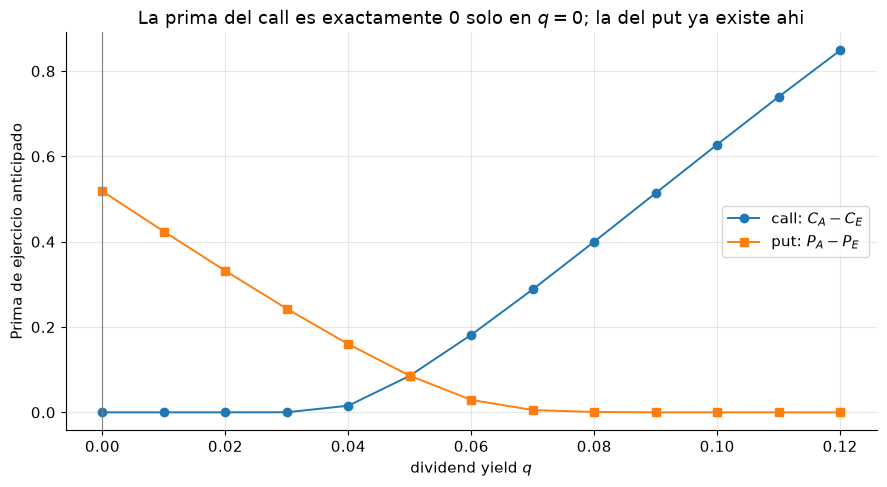

In [8]:
n_call = 1000
call_am, bnd_call, _ = crr_american(S0, K, r, q, sigma, T, n_call, "call")
call_eu, _, _ = crr_american(S0, K, r, q, sigma, T, n_call, "call", american=False)
print(f"q=0 -> call americano = {call_am:.12f}")
print(f"q=0 -> call europeo   = {call_eu:.12f}")
print(f"  diferencia = {abs(call_am - call_eu):.2e}  |  nodos con ejercicio: {int((~np.isnan(bnd_call)).sum())}")

q_grid = np.linspace(0.0, 0.12, 13)
premium_call, premium_put = [], []
for q_g in q_grid:
    ca, _, _ = crr_american(S0, K, r, q_g, sigma, T, n_call, "call")
    ce, _, _ = crr_american(S0, K, r, q_g, sigma, T, n_call, "call", american=False)
    pa, _, _ = crr_american(S0, K, r, q_g, sigma, T, n_call, "put")
    pe, _, _ = crr_american(S0, K, r, q_g, sigma, T, n_call, "put", american=False)
    premium_call.append(ca - ce)
    premium_put.append(pa - pe)

print(f"\nPrima de ejercicio anticipado del call:")
for idx in (0, 1, 2, len(q_grid) - 1):
    print(f"  q={q_grid[idx]:.2f} -> {premium_call[idx]:.3e}")
print(f"  frontera teorica en el vencimiento S*_call(T-) = K*max(1, r/q):")
for q_g in (0.01, 0.02, 0.05, 0.12):
    print(f"    q={q_g:.2f} -> S* = {K * max(1.0, r / q_g):.0f}")
print("  (la region de ejercicio es no vacia para todo q>0, pero con q<<r la frontera esta tan")
print("   arriba que llegar ahi es practicamente imposible y el arbol devuelve 0 exacto)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(q_grid, premium_call, "o-", label="call: $C_A - C_E$")
ax.plot(q_grid, premium_put, "s-", label="put: $P_A - P_E$")
ax.axvline(0.0, color="gray", lw=0.8)
ax.set_xlabel("dividend yield $q$"); ax.set_ylabel("Prima de ejercicio anticipado")
ax.set_title("La prima del call es exactamente $0$ solo en $q=0$; la del put ya existe ahi")
ax.legend()
plt.tight_layout()
plt.show()

assert call_am == call_eu, "with q=0 the American call must equal the European one exactly"

## 9. Validación contra QuantLib

Tres comparaciones, cada una con su tolerancia y su razón:

1. **Árbol CRR americano vs `BinomialVanillaEngine("crr", n)`**, `atol=1e-4` a $n=2000$. No es igualdad a precisión de máquina *a propósito*: como se anticipó en la §1, QuantLib usa la probabilidad linealizada y nosotros la exacta de no arbitraje, una diferencia $O(\Delta t)$. Verificamos que la discrepancia decae como $1/n$ (el producto diferencia$\times n$ debe ser constante), que es la evidencia de que se trata de la convención y no de un error.
2. **BAW propio vs `BaroneAdesiWhaleyApproximationEngine`**, `atol=1e-6`: aquí sí es el *mismo* algoritmo, y la única fuente de diferencia es la tolerancia del solver de $S^{**}$.
3. **Put perpetuo vs el límite del árbol**, `rtol=1e-2`: la fórmula de la §3 contra el árbol de $T=100$ de la Demo 1.

In [9]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()

maturity = eval_date + int(round(T * 365))
T_actual = day_count.yearFraction(eval_date, maturity)
american_exercise = ql.AmericanExercise(eval_date, maturity)

spot_quote = ql.SimpleQuote(S0)
rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
div_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q, day_count))
vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count))
process = ql.BlackScholesMertonProcess(ql.QuoteHandle(spot_quote), div_ts, rate_ts, vol_ts)

ql_put = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Put, K), american_exercise)
print(f"T_actual = {T_actual} (target T = {T})")

T_actual = 1.0 (target T = 1.0)


In [10]:
# --- 1. Arbol CRR americano vs QuantLib (convencion de p: diferencia O(1/n)) ---
print(f"{'n':>6} | {'QuantLib':>12} | {'propio':>12} | {'diff':>10} | {'diff*n':>8}")
print("-" * 60)
diff_times_n = []
for n_val in (250, 500, 1000, 2000):
    ql_put.setPricingEngine(ql.BinomialVanillaEngine(process, "crr", n_val))
    ql_val = ql_put.NPV()
    own_val, _, _ = crr_american(S0, K, r, q, sigma, T_actual, n_val, "put")
    diff = abs(ql_val - own_val)
    diff_times_n.append(diff * n_val)
    print(f"{n_val:>6} | {ql_val:>12.8f} | {own_val:>12.8f} | {diff:>10.2e} | {diff_times_n[-1]:>8.5f}")

np.testing.assert_allclose(own_val, ql_val, atol=1e-4)
print(f"CRR americano n=2000 vs QuantLib: dentro de atol=1e-4.")

spread_conv = max(diff_times_n) / min(diff_times_n)
print(f"diff*n en n=250..2000: {diff_times_n[0]:.5f} .. {diff_times_n[-1]:.5f} (razon {spread_conv:.4f}) "
      f"-> diferencia O(1/n), es la convencion de p")
assert abs(spread_conv - 1.0) <= 0.05

     n |     QuantLib |       propio |       diff |   diff*n
------------------------------------------------------------
   250 |   6.08728490 |   6.08717929 |   1.06e-04 |  0.02640
   500 |   6.08886292 |   6.08881011 |   5.28e-05 |  0.02641
  1000 |   6.08962169 |   6.08959528 |   2.64e-05 |  0.02641
  2000 |   6.09000316 |   6.08998995 |   1.32e-05 |  0.02641
CRR americano n=2000 vs QuantLib: dentro de atol=1e-4.
diff*n en n=250..2000: 0.02640 .. 0.02641 (razon 1.0004) -> diferencia O(1/n), es la convencion de p


In [11]:
# --- 2. BAW propio vs QuantLib (mismo algoritmo, atol 1e-6) ---
ql_put.setPricingEngine(ql.BaroneAdesiWhaleyApproximationEngine(process))
ql_baw = ql_put.NPV()
own_baw, own_S_crit = baw_american_put(S0, K, r, q, sigma, T_actual)
print(f"BAW -- QuantLib: {ql_baw:.10f} | propio: {own_baw:.10f} | diff: {abs(ql_baw - own_baw):.2e}")
np.testing.assert_allclose(own_baw, ql_baw, atol=1e-6)
print(f"BAW: dentro de atol=1e-6.  (S** = {own_S_crit:.6f})")

BAW -- QuantLib: 6.0976153816 | propio: 6.0976153810 | diff: 6.37e-10
BAW: dentro de atol=1e-6.  (S** = 81.695434)


In [12]:
# --- 3. Put perpetuo vs el limite del arbol (T=100 de la Demo 1) ---
rel_err_perp = abs(perp_binomial[-1] - float(perp_value)) / float(perp_value)
print(f"Perpetuo -- analitico: {float(perp_value):.6f} | binomial T={T_horizons[-1]}: {perp_binomial[-1]:.6f} "
      f"| error relativo: {rel_err_perp:.3%}")
np.testing.assert_allclose(perp_binomial[-1], float(perp_value), rtol=1e-2)
print("Put perpetuo: dentro de rtol=1e-2 del limite binomial.")

print()
print("Validacion completa: 3/3 dentro de tolerancia.")

Perpetuo -- analitico: 12.320033 | binomial T=100: 12.317920 | error relativo: 0.017%
Put perpetuo: dentro de rtol=1e-2 del limite binomial.

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Barone-Adesi, G. & Whaley, R.E. (1987). *Efficient Analytic Approximation of American Option Values*. Journal of Finance, 42(2), 301-320.
- MacMillan, L.W. (1986). *Analytic Approximation for the American Put Option*. Advances in Futures and Options Research, 1, 119-139.
- Merton, R.C. (1973). *Theory of Rational Option Pricing*. Bell Journal of Economics and Management Science, 4(1), 141-183. (put perpetuo, §8; cotas del call americano)
- Snell, J.L. (1952). *Applications of Martingale System Theorems*. Transactions of the AMS, 73(2), 293-312. (la envolvente que lleva su nombre)
- Shreve, S.E. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, Springer, cap. 4 (parada óptima y envolvente de Snell en el árbol).
- Peskir, G. & Shiryaev, A. (2006). *Optimal Stopping and Free-Boundary Problems*, Birkhauser, caps. 1-2 (tratamiento riguroso; smooth pasting).
- Wilmott, P. (2006). *Paul Wilmott on Quantitative Finance*, 2nd ed., Wiley, caps. 27-28 (frontera libre, desigualdad variacional).
- Hull, J.C. *Options, Futures, and Other Derivatives*, 10th ed., cap. 21 (árboles para americanas) y §11.5 (call americano sin dividendos).